# Regression Analysis


This notebook aims to answer the question: **"How much did the tariff shock independently contribute to the changes in spread"**

For example, NVDA had wider spreads during Phase 2 — but NVDA options also tend to have shorter DTE and higher volatility. I seek to use regression to isolate the phase effect from those confounders.

We build three models in order of complexity:

| Model | Purpose |
|-------|---------|
| **OLS (main effects)** | Base model, how much does each variable shift spreads? |
| **OLS (interactions)** | Tests how the tariffs hit different sectors differently |
| **Random Forest** | Better predictive accuracy, feature importance shows what matters most |

**Dataset:** all liquid (bid > 0) contracts with valid realised volatility — 49,473 rows across all tickers, phases, and moneyness levels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


PROJECT_ROOT = Path().resolve().parent
COMBINED_CSV = PROJECT_ROOT / "data" / "combined" / "combined_all.csv"

#Global Params
plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         10,
})


df = pd.read_csv(
    COMBINED_CSV,
    parse_dates=["collection_date"],
    dtype={"ticker": str, "side": str, "moneyness_cat": str},
)
df["is_illiquid"] = df["is_illiquid"].astype(bool)

liquid = df[~df["is_illiquid"]].copy()

# Drop rows missing key features
reg_df = liquid.dropna(subset=["relative_spread", "realised_vol", "dte", "moneyness_pct"])
reg_df = reg_df[reg_df["relative_spread"] > 0].copy()

print(f"Regression dataset: {len(reg_df):,} rows")
print(f"Tickers : {sorted(reg_df['ticker'].unique())}")
print(f"Phases  : {sorted(reg_df['phase'].unique())}")

---
## Variable Selection

Target Variable: `relative_spread`

We hypothesise that the following variables would act as the best predictors as they are known drivers of option bid-ask spreads:

| Variable | Raw Column | Hypothesis |
|---|---|---|
| Time to expiry | `dte` | Shorter-dated options carry higher gamma risk for market makers → wider spreads |
| Moneyness | `moneyness_pct` | Deep OTM and deep ITM options are less liquid → wider spreads |
| Option type | `side` | Put demand can differ from calls → spreads may differ |
| Realised volatility | `realised_vol` | Higher vol → higher inventory risk for market makers → wider spreads |
| Open interest | `openInterest` | More OI = more trading interest = deeper market → tighter spreads |
| Tariff phase | `phase` | Phase 2 = shock period, Phase 3 = recovery, we want to isolate this effect |
| Ticker | `ticker` | Controls for structural spread differences between stocks |

All other columns are metadata (e.g. `collection_date`, `moneyness_cat`, `is_illiquid`) and will be dropped before modelling.


---
## Multicollinearity Check

To fulfill OLS Assumptions, we need to make sure our numeric predictors don't exhibit signs of multicollinearity.

Observing the Pearson Correlation Matrix, we see that there is low correlation between numeric predictor variables.

In [ ]:
import seaborn as sns

predictors = ["dte", "moneyness_pct", "openInterest", "realised_vol"]

corr_predictor = reg_df[predictors].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_predictor,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask = np.triu(np.ones_like(corr_predictor, dtype=bool)),
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix — Predictor Variables")
plt.tight_layout()
#plt.savefig("../outputs/correlation_matrix_raw.png", dpi=150, bbox_inches="tight")
plt.show()


## Skewness Check

To fulfill Normality Assumptions for OLS, we check the distribution of each variable.
Right skewed variables will require log-transforms in the feature engineering stage.

After checking for skew, we can narrow down the variables that need the log-transform to:
- `openInterest`
- `relative_spread`

In [ ]:
# Change (2, 5) to (1, 5)
fig, axes = plt.subplots(1, 5, figsize=(18, 4)) 

for ax, col in zip(axes, predictors):
    reg_df[col].hist(bins=60, ax=ax, edgecolor="none", color="#2196F3", alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Skewness of Predictor Variables", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

print("Skewness of each predictor variable: ")
for col in predictors:
    skew = reg_df[col].skew()
    print(f"  {col:<20} skew = {skew:+.2f}")

## Feature Engineering

1. Log-Transform the following variables:
- `openInterest`
- `relative_spread`

2. Other Engineered Features:
- `dte` -> make sure no days-to-expiry are less than 1
- `moneyness_pct` -> get absolute percentages
- `phase` -> split phase into phase 2 and phase 3
- `side` -> change into a binary feature where 1 represents puts and 0 represents calls

3. We keep `realised_vol` the same

Final Features in our Dataset:
| Feature |
| --- |
| `openInterest` |
| `relative_spread` |
| `adjusted_dte` |
| `is_put` |
| `abs_moneyness_pct` |
| `phase_2` |
| `phase_3` |

In [ ]:
#normalising variables
reg_df["log_relative_spread"] = np.log(reg_df["relative_spread"])
reg_df["log_oi"]  = np.log1p(reg_df["openInterest"])


reg_df["adjusted_dte"] = reg_df["dte"].clip(lower=1)
reg_df["abs_moneyness_pct"] = reg_df["moneyness_pct"].abs()
reg_df["is_put"] = (reg_df["side"] == "put").astype(int)
reg_df["phase_2"] = (reg_df["phase"] == 2).astype(int)
reg_df["phase_3"] = (reg_df["phase"] == 3).astype(int)

print("Feature Engineering Done.")

---
## Final Correlation Check

After Feature Engineering, we do a final check for multicollinearity. 

The following variable-pairs are flagged:
- `phase 2` x `phase 3`: Mutually Exclusive variables from the same initial categorical variable `phase`. Correlation is to be expected.
- `phase 2`/`phase 3` x `realised vol`:  The tariff shock period would naturally lead to higher market volatility. Correlation is to be expected.

The remaining variable-pairs do not exhibit high correlation. We can carry on with our OLS regression model.


In [ ]:
final_features = [
    "realised_vol",
    "adjusted_dte",
    "abs_moneyness_pct",
    "is_put",
    "log_oi",
    "phase_2",
    "phase_3",
    "log_relative_spread",
]

final_corr_matrix = reg_df[final_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    final_corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    mask = np.triu(np.ones_like(final_corr_matrix, dtype=bool)),
    linewidths=0.5,
    ax=ax
)

ax.set_title("Final Correlation Matrix")
plt.tight_layout()
#plt.savefig("../outputs/final_correlation_matrix.png", dpi=150)
plt.show()

---
## Creating Regression Dataframe

Dropping all irrelevant columns and keeping only the engineered features

In [ ]:
reg_df = reg_df[final_features].copy()

print(f"reg_df shape after dropping irrelevant columns: {reg_df.shape}")
reg_df.head()

---
## Model 1 — OLS: Main Effects

This is the baseline model. Each coefficient tells you the expected change in `log(relative_spread)` associated with a one-unit increase in that variable, while holding everything else constant.

**Reference categories:**
- Ticker: AAPL (so `ticker_NVDA` means "compared to AAPL")
- Phase: Phase 1 / baseline (so `phase_2` means "compared to pre-shock")
- Side: call (so `is_put` means "compared to calls")

In [53]:
olsformula_1 = (
    "log_relative_spread ~ "
    "C(ticker, Treatment('AAPL')) + "
    "phase_2 + phase_3 + "
    "realised_vol + adjusted_dte + abs_moneyness_pct + is_put + log_oi"
)

model_1 = smf.ols(olsformula_1, data=reg_df).fit()

# Build a clean results table -- the default statsmodels summary is verbose
results_ols1 = pd.DataFrame({
    "Coefficient":  model_1.params.round(4),
    "Std Error":    model_1.bse.round(4),
    "p-value":      model_1.pvalues.round(4),
    "[95% CI low]": model_1.conf_int()[0].round(4),
    "[95% CI hi]": model_1.conf_int()[1].round(4),
    "Sig":          model_1.pvalues.apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ),
})

print("OLS Model 1 — Main Effects")
print("=" * 75)
print(results_ols1.to_string())
print()
print(f"R²     = {model_1.rsquared:.4f}")
print(f"Adj R² = {model_1.rsquared_adj:.4f}")
print(f"N      = {int(model_1.nobs):,}")

OLS Model 1 — Main Effects
                                      Coefficient  Std Error  p-value  [95% CI low]  [95% CI hi]  Sig
Intercept                                 -3.8262     0.0254      0.0       -3.8760      -3.7765  ***
C(ticker, Treatment('AAPL'))[T.AMZN]      -0.2622     0.0129      0.0       -0.2875      -0.2370  ***
C(ticker, Treatment('AAPL'))[T.CAT]        1.2503     0.0145      0.0        1.2218       1.2788  ***
C(ticker, Treatment('AAPL'))[T.NVDA]      -0.6056     0.0135      0.0       -0.6321      -0.5792  ***
C(ticker, Treatment('AAPL'))[T.PG]         1.6057     0.0165      0.0        1.5734       1.6380  ***
phase_2                                   -0.1676     0.0233      0.0       -0.2134      -0.1219  ***
phase_3                                   -0.1024     0.0197      0.0       -0.1410      -0.0637  ***
realised_vol                               0.5715     0.0363      0.0        0.5004       0.6426  ***
adjusted_dte                              -0.0067     0

---
## Model 2 — OLS: Asymmetric Shock (Interaction Terms)

Model 1 assumes the tariff shock affected all tickers equally (a single `phase_2` coefficient). But the EDA and statistical tests suggested NVDA was hit harder than others.

Model 2 adds **`ticker × phase_2` interaction terms**. This lets each ticker have its own Phase 2 effect. 

In [56]:
olsformula_2 = (
    "log_relative_spread ~ "
    "C(ticker, Treatment('AAPL')) * phase_2 + "
    "phase_3 + "
    "realised_vol + adjusted_dte + abs_moneyness_pct + "
    "is_put + log_oi + log_vol"
)

model_2 = smf.ols(olsformula_2, data=reg_df).fit()

# Extract only the interaction terms and phase_2 baseline for readability
interaction_rows = [
    idx for idx in model_2.params.index
    if "phase_2" in idx
]

results_ols2 = pd.DataFrame({
    "Coefficient":  model_2.params[interaction_rows].round(4),
    "p-value":      model_2.pvalues[interaction_rows].round(4),
    "Multiplier":   np.exp(model_2.params[interaction_rows]).round(4),
    "Sig":          model_2.pvalues[interaction_rows].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ),
})

print("OLS Model 2 — Phase 2 effects and ticker interactions")
print("=" * 65)
print(results_ols2.to_string())
print()
print(f"R²     = {model_2.rsquared:.4f}  (Model 1 R² = {model_1.rsquared:.4f})")
print(f"Adj R² = {model_2.rsquared_adj:.4f}")
print(f"N      = {int(model_2.nobs):,}")

OLS Model 2 — Phase 2 effects and ticker interactions
                                              Coefficient  p-value  Multiplier  Sig
phase_2                                           -0.0780   0.0035      0.9250   **
C(ticker, Treatment('AAPL'))[T.AMZN]:phase_2       0.0866   0.0012      1.0904   **
C(ticker, Treatment('AAPL'))[T.CAT]:phase_2       -0.0625   0.0246      0.9394    *
C(ticker, Treatment('AAPL'))[T.NVDA]:phase_2       0.0744   0.0044      1.0772   **
C(ticker, Treatment('AAPL'))[T.PG]:phase_2        -0.3462   0.0000      0.7074  ***

R²     = 0.4313  (Model 1 R² = 0.4268)
Adj R² = 0.4311
N      = 49,473


---
## Model 3 — Random Forest

OLS assumes a linear relationship between each predictor and the log-spread. 

We use Random Forest to capture non-linear effects and interactions. We give up interpretability for feature importance

- We use an 80/20 train/test split to get an honest estimate of how well the model generalises to unseen data. 
- We use R² on the test set to check for overfitting.

In [59]:
ticker_dummies = pd.get_dummies(reg_df["ticker"], prefix="ticker").drop(columns=["ticker_AAPL"])

FEATURE_COLS = [
    "phase_2", "phase_3",
    "realised_vol",
    "adjusted_dte",
    "abs_moneyness_pct",
    "is_put",
    "log_oi",
]

X = pd.concat([reg_df[FEATURE_COLS].reset_index(drop=True),
               ticker_dummies.reset_index(drop=True)], axis=1)
y = reg_df["log_relative_spread"].reset_index(drop=True)

all_features = X.columns.tolist()

# 80/20 split -- random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")
print(f"Features     : {len(all_features)}")
print()
print("Fitting Random Forest (100 trees)...")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,        # limit depth to reduce overfitting
    min_samples_leaf=20, # each leaf must have at least 20 observations
    random_state=42,
    n_jobs=-1,           # use all CPU cores
)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print(f"Train R² = {r2_train:.4f}  |  Train RMSE = {rmse_train:.4f}")
print(f"Test  R² = {r2_test:.4f}  |  Test  RMSE = {rmse_test:.4f}")

Training set : 39,578 rows
Test set     : 9,895 rows
Features     : 11

Fitting Random Forest (100 trees)...
Train R² = 0.6956  |  Train RMSE = 0.6725
Test  R² = 0.6512  |  Test  RMSE = 0.7221


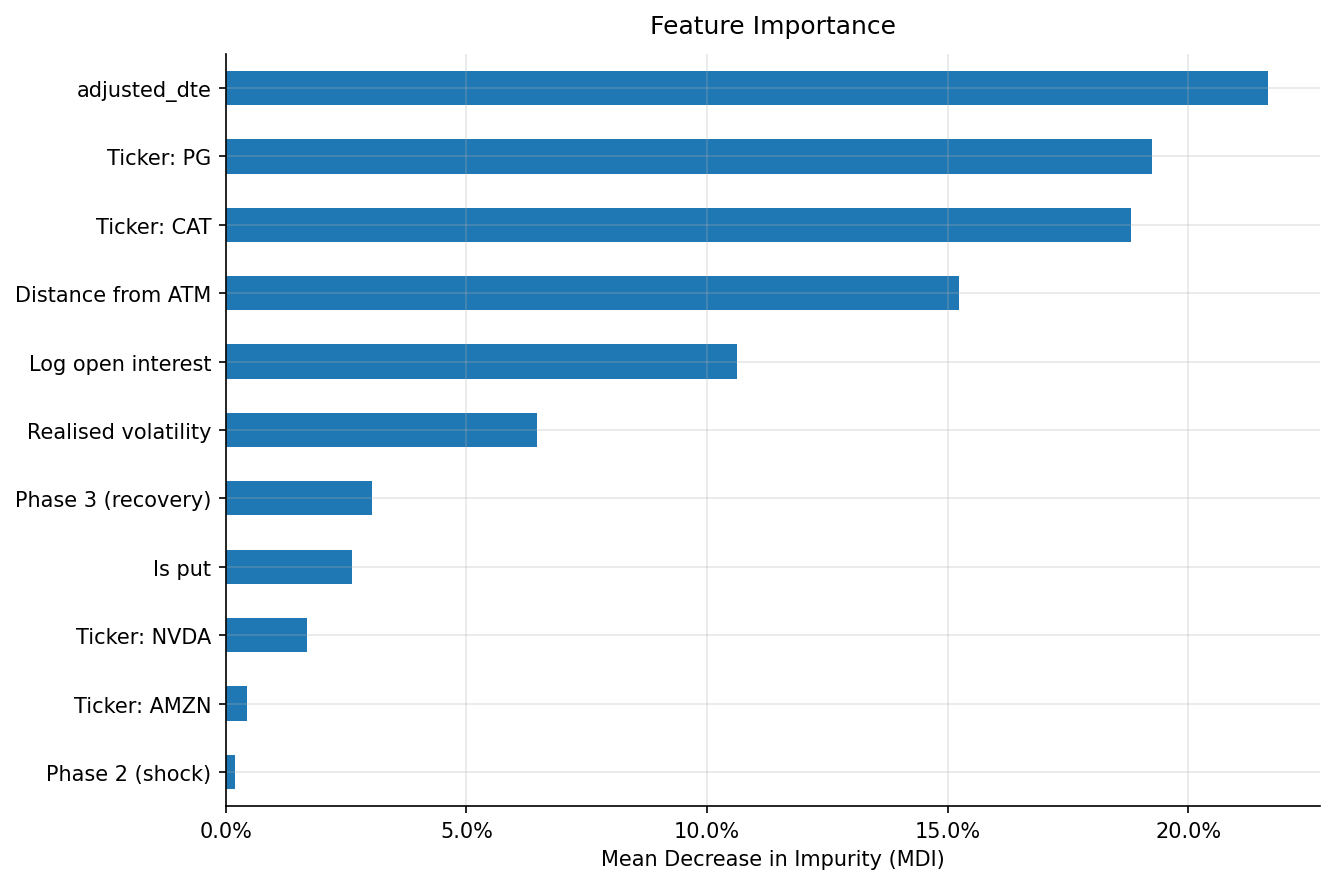

In [70]:
# Feature importance plot
importances = (
    pd.Series(rf.feature_importances_, index=all_features)
    .sort_values(ascending=True)
)

# Rename for readability on the chart
label_map = {
    "phase_2":           "Phase 2 (shock)",
    "phase_3":           "Phase 3 (recovery)",
    "realised_vol":      "Realised volatility",
    "log_dte":           "Log DTE",
    "abs_moneyness_pct": "Distance from ATM",
    "is_put":            "Is put",
    "log_oi":            "Log open interest",
    "log_vol":           "Log volume",
    "ticker_NVDA":       "Ticker: NVDA",
    "ticker_AMZN":       "Ticker: AMZN",
    "ticker_PG":         "Ticker: PG",
    "ticker_CAT":        "Ticker: CAT",
}
importances.index = [label_map.get(i, i) for i in importances.index]

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot.barh(ax=ax, edgecolor="none")
ax.set_title("Feature Importance",
             fontsize=12, pad=10)
ax.set_xlabel("Mean Decrease in Impurity (MDI)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

from matplotlib.patches import Patch

fig.tight_layout()

# save(fig, "fig_rf_importance.png")
plt.show()

---
## Model Comparison

In [66]:
# OLS in-sample RMSE for comparison
ols1_resid = model_1.resid
ols2_resid = model_2.resid
rmse_ols1 = np.sqrt((ols1_resid ** 2).mean())
rmse_ols2 = np.sqrt((ols2_resid ** 2).mean())

comparison = pd.DataFrame({
    "Model":          ["OLS (main effects)", "OLS (interactions)", "Random Forest"],
    "R²":             [round(model_1.rsquared, 4),
                       round(model_2.rsquared, 4),
                       round(r2_test, 4)],
    "Adj R²":         [round(model_1.rsquared_adj, 4),
                       round(model_2.rsquared_adj, 4),
                       "—"],
    "RMSE":           [round(rmse_ols1, 4),
                       round(rmse_ols2, 4),
                       round(rmse_test, 4)],
    "N":              [f"{int(model_1.nobs):,}",
                       f"{int(model_2.nobs):,}",
                       f"{len(X_test):,} (test)"],
    "Note":           ["In-sample", "In-sample", "Out-of-sample"]
}).set_index("Model")

print(comparison.to_string())


                        R²  Adj R²    RMSE             N           Note
Model                                                                  
OLS (main effects)  0.4268  0.4267  0.9233        49,473      In-sample
OLS (interactions)  0.4313  0.4311  0.9198        49,473      In-sample
Random Forest       0.6512       —  0.7221  9,895 (test)  Out-of-sample


---
## Key Findings from the Regression

In [68]:
print("KEY FINDINGS")
print("=" * 70)
print()

# Phase 2 effect from Model 1
phase2_coef = model_1.params["phase_2"]
phase2_mult = np.exp(phase2_coef)
phase2_sig  = model_1.pvalues["phase_2"]
print("1. Tariff shock independently widened spreads (Model 1)")
print(f"   phase_2 coef = {phase2_coef:+.4f}  →  spreads {phase2_mult:.3f}x wider during Phase 2")
print(f"   p = {phase2_sig:.4f}  {'***' if phase2_sig < 0.001 else '**' if phase2_sig < 0.01 else '*' if phase2_sig < 0.05 else 'ns'}")
print(f"   This holds after controlling for volatility, DTE, moneyness, and sector.")
print()

# Phase 3 effect
phase3_coef = model_1.params["phase_3"]
phase3_mult = np.exp(phase3_coef)
print("2. Recovery: Phase 3 spreads vs baseline (Model 1)")
print(f"   phase_3 coef = {phase3_coef:+.4f}  →  spreads {phase3_mult:.3f}x vs baseline in Phase 3")
print(f"   {'Spreads overshot baseline (tighter than pre-shock) even after controls.' if phase3_coef < 0 else 'Spreads still elevated in Phase 3 after controls.'}")
print()

# NVDA interaction
nvda_int_key = "C(ticker, Treatment('AAPL'))[T.NVDA]:phase_2"
if nvda_int_key in model_2.params:
    nvda_int = model_2.params[nvda_int_key]
    nvda_total = model_2.params["phase_2"] + nvda_int
    nvda_sig = model_2.pvalues[nvda_int_key]
    print("3. NVDA shock premium over AAPL (Model 2 interaction)")
    print(f"   NVDA interaction coef = {nvda_int:+.4f}")
    print(f"   Total Phase 2 effect for NVDA = {nvda_total:+.4f}  ({np.exp(nvda_total):.3f}x)")
    print(f"   p = {nvda_sig:.4f}  — {'significant: NVDA absorbed a larger shock than AAPL after controls' if nvda_sig < 0.05 else 'not significant after controlling for other variables'}")
print()

# Most important features from RF
top3 = importances.sort_values(ascending=False).head(3)
print("4. Most important predictors of spread (Random Forest)")
for feat, imp in top3.items():
    print(f"   {feat:<30} {imp:.4f} ({imp*100:.1f}% of variance)")
print()

print(f"5. Model fit")
print(f"   OLS R² = {model_1.rsquared:.4f} — linear controls explain {model_1.rsquared*100:.1f}% of log-spread variance")
print(f"   RF test R² = {r2_test:.4f} — non-linear model explains {r2_test*100:.1f}% out of sample")

KEY FINDINGS

1. Tariff shock independently widened spreads (Model 1)
   phase_2 coef = -0.1676  →  spreads 0.846x wider during Phase 2
   p = 0.0000  ***
   This holds after controlling for volatility, DTE, moneyness, and sector.

2. Recovery: Phase 3 spreads vs baseline (Model 1)
   phase_3 coef = -0.1024  →  spreads 0.903x vs baseline in Phase 3
   Spreads overshot baseline (tighter than pre-shock) even after controls.

3. NVDA shock premium over AAPL (Model 2 interaction)
   NVDA interaction coef = +0.0744
   Total Phase 2 effect for NVDA = -0.0036  (0.996x)
   p = 0.0044  — significant: NVDA absorbed a larger shock than AAPL after controls

4. Most important predictors of spread (Random Forest)
   adjusted_dte                   0.2166 (21.7% of variance)
   Ticker: PG                     0.1924 (19.2% of variance)
   Ticker: CAT                    0.1882 (18.8% of variance)

5. Model fit
   OLS R² = 0.4268 — linear controls explain 42.7% of log-spread variance
   RF test R² = 0.65